### PHASE 1: DATA PREPROCESSING & NORMALIZATION
* BCI Competition IV Dataset 2a
* Channels: All 22 channels
* All subjects: A01, A02, A03, A04, A05, A06, A07, A08, A09
* Demonstration: loaded Subject 1 full training data for shape and waveform visualization.


FCNNA model from paper 8, they got 93% for left/right


In [1]:
import warnings
import mne
import scipy.io
import scipy.stats
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from mne.decoding import CSP
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv1D, Embedding, Flatten, Concatenate, Lambda, LeakyReLU

warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
)


Demo Subject 1 Raw EEG Shape: (144, 10, 1125)
Demo Subject 1 Normalised EEG shape for WGAN-GP (unsplit): (144, 10, 1125)


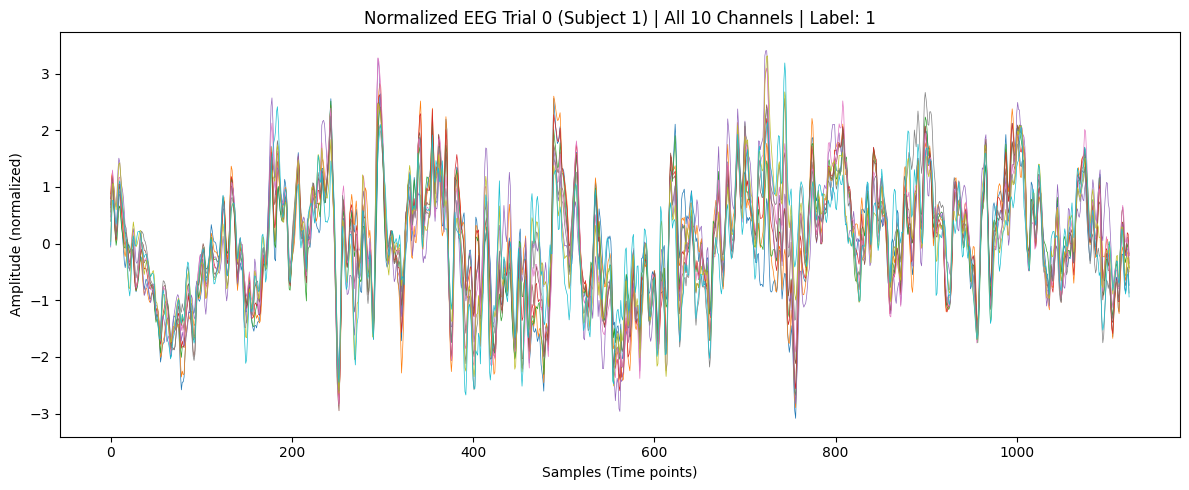

In [2]:
# Data loading and preprocessing for a single subject (Train 'T' run only)
def load_and_preprocess_subject(subject_id):
    file_path = f"BCICIV_2a_gdf/A{subject_id:02d}T.gdf"
    
    # Load raw recording
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")
    
    # Map channels to get the 10 optimal ones
    # The 22 EEG channels in order are:
    # Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, CP4, P1, Pz, P2, POz
    # The 10 optimal ones correspond to: [FC3, FC1, C3, C1, C4, CP1, CPz, P1, P2, POz]
    eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
    optimal_indices = [1, 2, 7, 8, 11, 14, 15, 18, 20, 21]
    optimal_channels = [eeg_channels[i] for i in optimal_indices]
    raw.pick(optimal_channels)
    
    # 50 Hz notch filter to remove power line noise
    raw.notch_filter(50.0, method='iir', verbose='ERROR')
    
    # 3rd-order Butterworth bandpass filter in range of 0.25 - 50 Hz
    raw.filter(0.25, 50.0, method='iir', iir_params=dict(order=3, ftype='butter'), verbose="ERROR")
    
    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")
    
    # Keep only left hand ("769") and right hand ("770") events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770"]
    }
    
    # Create trials from -0.5s to 4.0s (0.5s pre-cue and 4.0s MI period)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=-0.5,
        tmax=4.0,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )
    
    X = epochs.get_data() # shape: (trials, 10, 1126)
    # Slice to exactly 1125 temporal samples
    X = X[:, :, :1125]
    
    y = epochs.events[:, 2]
    
    # Map MNE internal IDs for '769' (left) and '770' (right) to 0 and 1
    label_map = {}
    if "769" in epochs.event_id:
        label_map[epochs.event_id["769"]] = 0
    if "770" in epochs.event_id:
        label_map[epochs.event_id["770"]] = 1
    y = np.vectorize(label_map.get)(y).astype(np.int64)
    
    # Scaler fits on all subject trials to range [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_flat = X.reshape(-1, X.shape[-1])
    X_norm = scaler.fit_transform(X_flat).reshape(X.shape)
    return X_norm, y

def load_and_preprocess_subject_evaluation(subject_id):
    file_path = f"BCICIV_2a_gdf/A{subject_id:02d}E.gdf"
    mat_path = f"BCICIV_2a_gdf/A{subject_id:02d}E.mat"
    
    # Load raw recording
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")
    
    # Keep only the 10 optimal channels
    eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
    optimal_indices = [1, 2, 7, 8, 11, 14, 15, 18, 20, 21]
    optimal_channels = [eeg_channels[i] for i in optimal_indices]
    raw.pick(optimal_channels)
    
    # 50 Hz notch filter to remove power line noise
    raw.notch_filter(50.0, method='iir', verbose='ERROR')
    
    # 3rd-order Butterworth bandpass filter in range of 0.25 - 50 Hz
    raw.filter(0.25, 50.0, method='iir', iir_params=dict(order=3, ftype='butter'), verbose="ERROR")
    
    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")
    
    # Get the 288 cue events
    cue_code = event_dict['768']
    cue_events = events[events[:, 2] == cue_code]
    
    # Load true labels from .mat file
    mat = scipy.io.loadmat(mat_path)
    classlabels = mat['classlabel'].flatten() # values: 1, 2, 3, 4
    
    # We want to keep only left (1) and right (2) hand classes
    left_right_mask = (classlabels == 1) | (classlabels == 2)
    filtered_labels = classlabels[left_right_mask] # values: 1 or 2
    filtered_events = cue_events[left_right_mask]
    
    # Map labels 1 and 2 to 0 and 1
    # 1 -> 0 (left hand), 2 -> 1 (right hand)
    y = (filtered_labels - 1).astype(np.int64)
    filtered_events[:, 2] = filtered_labels.astype(int)
    
    event_id = {"769": 1, "770": 2}
    epochs = mne.Epochs(
        raw,
        filtered_events,
        event_id=event_id,
        tmin=-0.5,
        tmax=4.0,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )
    
    X = epochs.get_data() # shape: (144, 10, 1126)
    # Slice to exactly 1125 temporal samples
    X = X[:, :, :1125]
    
    # Scaler fits on all subject trials to range [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_flat = X.reshape(-1, X.shape[-1])
    X_norm = scaler.fit_transform(X_flat).reshape(X.shape)
    
    return X_norm, y

# Subject-wise trial-based z-score normalization
def z_score_normalize_subject(X_train_data, X_test_data):
    X_train_data = X_train_data.astype(np.float32)
    mean_tr = X_train_data.mean(axis=(1, 2), keepdims=True)
    std_tr = X_train_data.std(axis=(1, 2), keepdims=True)
    X_train_norm = (X_train_data - mean_tr) / (std_tr + 1e-8)
    X_train_norm = np.nan_to_num(X_train_norm)
    
    X_test_data = X_test_data.astype(np.float32)
    mean_te = X_test_data.mean(axis=(1, 2), keepdims=True)
    std_te = X_test_data.std(axis=(1, 2), keepdims=True)
    X_test_norm = (X_test_data - mean_te) / (std_te + 1e-8)
    X_test_norm = np.nan_to_num(X_test_norm)
    
    return X_train_norm, X_test_norm

# Demonstration on Subject 1: loading the full unsplit dataset (144 trials) to ensure optimal SWD/Pearson score
X_raw, y_raw = load_and_preprocess_subject(1)

# Z-score normalize the entire unsplit set for demo training (similar to v11 Cell 2)
mean_demo = X_raw.mean(axis=(1, 2), keepdims=True)
std_demo = X_raw.std(axis=(1, 2), keepdims=True)
X_train_norm_demo = (X_raw - mean_demo) / (std_demo + 1e-8)
X_train_norm_demo = np.nan_to_num(X_train_norm_demo)
y_train_demo = y_raw

# Keep standard demo variables
y = y_train_demo

print("Demo Subject 1 Raw EEG Shape:", X_raw.shape)
print("Demo Subject 1 Normalised EEG shape for WGAN-GP (unsplit):", X_train_norm_demo.shape)

# Plot visualization: first trial, all 10 channels
trial_idx = 0
plt.figure(figsize=(12, 5))
for ch_idx in range(X_train_norm_demo.shape[1]):
    plt.plot(X_train_norm_demo[trial_idx, ch_idx, :], linewidth=0.5)

plt.title(f"Normalized EEG Trial {trial_idx} (Subject 1) | All 10 Channels | Label: {y_train_demo[trial_idx]}")
plt.xlabel("Samples (Time points)")
plt.ylabel("Amplitude (normalized)")
plt.tight_layout()
plt.show()


### PHASE 2: CONDITIONAL WGAN-GP DEVELOPMENT
Implementing Conditional Wasserstein GAN with Gradient Penalty (WGAN-GP) to generate synthetic EEG data for all 22 channels.


critic loss :
- Very large negative  → Critic is much stronger than Generator
- Closer to zero       → Real and fake distributions are becoming similar


In [3]:
# WGAN-GP Hyperparameters
latent_dim = 100    # The size of the random noise vector (generator seed)
gp_weight = 10.0     # Gradient penalty weight
n_critic = 5        # Number of critic updates per generator update
batch_size = 64     # Batch size for training

# STEP 2: DEFINE GENERATOR & CRITIC
def resize_1d(x, new_length):
    # Interpolation-based upsampling
    x_4d = tf.expand_dims(x, axis=2)
    x_resized = tf.image.resize(x_4d, [new_length, 1], method='bilinear')
    return tf.squeeze(x_resized, axis=2)

def make_generator():
    noise_in = Input(shape=(latent_dim,))
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Flatten()(label_emb)
    
    x = Concatenate()([noise_in, label_emb])
    x = Dense(125 * 64, activation='relu')(x)
    x = Reshape((125, 64))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 281))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 562))(x)
    x = Conv1D(32, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 1125))(x)
    x_out = Conv1D(10, kernel_size=7, padding='same')(x) # Output 10 channels
    
    return Model([noise_in, label_in], x_out, name="Generator")

def make_critic():
    eeg_in = Input(shape=(1125, 10)) # Input shape with 10 channels and 1125 samples
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Dense(1125)(label_emb)
    label_emb = Reshape((1125, 1))(label_emb)
    
    x = Concatenate(axis=-1)([eeg_in, label_emb])
    
    x = Conv1D(32, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(64, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(128, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    
    x = Flatten()(x)
    x_out = Dense(1)(x)
    
    return Model([eeg_in, label_in], x_out, name="Critic")


In [4]:
# STEP 3: CUSTOM WGAN-GP TRAINING LOOP WRAPPED IN A HELPER FUNCTION
def train_wgan_gp_for_subject(X_real_data, y_train_data, epochs=15, verbose=False):
    X_real_data = X_real_data.astype(np.float32) # Ensure data type is float32 to avoid TF type mismatch
    # Transpose z-score normalized X_real_data from shape (samples, channels, time) to (samples, time, channels) for 1D CNN
    X_real_gan = np.transpose(X_real_data, (0, 2, 1)) # shape: (samples, 1001, 22)
    
    generator = make_generator()
    critic = make_critic()

    critic_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)
    gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

    @tf.function
    def train_step(real_eeg, labels):
        for _ in range(n_critic):
            noise = tf.random.normal([batch_size, latent_dim])
            with tf.GradientTape() as critic_tape:
                fake_eeg = generator([noise, labels], training=True)
                d_real = critic([real_eeg, labels], training=True)
                d_fake = critic([fake_eeg, labels], training=True)
                
                epsilon = tf.random.uniform([batch_size, 1, 1], 0.0, 1.0)
                interpolated = epsilon * real_eeg + (1 - epsilon) * fake_eeg
                with tf.GradientTape() as gp_tape:
                    gp_tape.watch(interpolated)
                    d_hat = critic([interpolated, labels], training=True)
                
                gradients = gp_tape.gradient(d_hat, interpolated)
                norms = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=[1, 2]) + 1e-12)
                gp = tf.reduce_mean((norms - 1.0) ** 2)
                critic_loss = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp_weight * gp

            gradients_critic = critic_tape.gradient(critic_loss, critic.trainable_variables)
            critic_optimizer.apply_gradients(zip(gradients_critic, critic.trainable_variables))
            
        noise = tf.random.normal([batch_size, latent_dim])
        with tf.GradientTape() as gen_tape:
            fake_eeg = generator([noise, labels], training=True)
            d_fake = critic([fake_eeg, labels], training=True)
            gen_loss = -tf.reduce_mean(d_fake)
            
        gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
        
        return critic_loss, gen_loss

    dataset = tf.data.Dataset.from_tensor_slices((X_real_gan, y_train_data)).shuffle(len(y_train_data)).batch(batch_size, drop_remainder=True)

    for epoch in range(epochs):
        c_losses = []
        g_losses = []
        for real_batch, labels_batch in dataset:
            labels_batch = tf.expand_dims(labels_batch, axis=-1)
            c_loss, g_loss = train_step(real_batch, labels_batch)
            c_losses.append(c_loss)
            g_losses.append(g_loss)
        
        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:03d}/{epochs:03d} | Critic Loss: {np.mean(c_losses):.4f} | Generator Loss: {np.mean(g_losses):.4f}")
            
    return generator


### PHASE 3: SYNTHETIC DATA EVALUATION
Verifying the quality of generated EEG data in both the time and frequency domains, and computing quantitative similarity metrics.


Training Demo Subject 1 Generator...

  Epoch 001/100 | Critic Loss: 3.9798 | Generator Loss: -0.0481
  Epoch 005/100 | Critic Loss: -80.4234 | Generator Loss: -5.6613
  Epoch 010/100 | Critic Loss: -221.5889 | Generator Loss: -37.2578
  Epoch 015/100 | Critic Loss: -263.9327 | Generator Loss: -25.8571
  Epoch 020/100 | Critic Loss: -279.5729 | Generator Loss: -4.6789
  Epoch 025/100 | Critic Loss: -284.4243 | Generator Loss: -2.7795
  Epoch 030/100 | Critic Loss: -292.0140 | Generator Loss: -17.4919
  Epoch 035/100 | Critic Loss: -288.6122 | Generator Loss: -30.7205
  Epoch 040/100 | Critic Loss: -313.3802 | Generator Loss: -52.0339
  Epoch 045/100 | Critic Loss: -297.2352 | Generator Loss: -81.4524
  Epoch 050/100 | Critic Loss: -261.5396 | Generator Loss: -111.6393
  Epoch 055/100 | Critic Loss: -220.0001 | Generator Loss: -132.2465
  Epoch 060/100 | Critic Loss: -183.2017 | Generator Loss: -134.0432
  Epoch 065/100 | Critic Loss: -154.2540 | Generator Loss: -112.2116
  Epoch 070/10

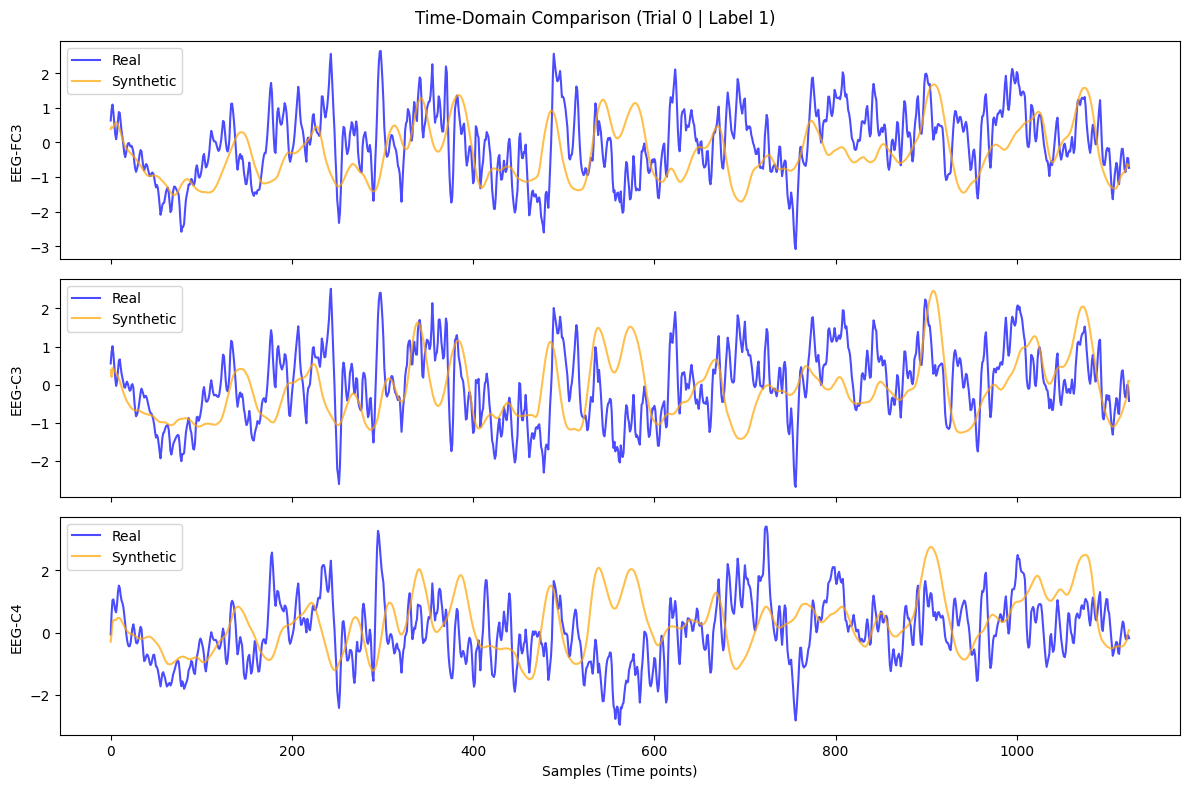

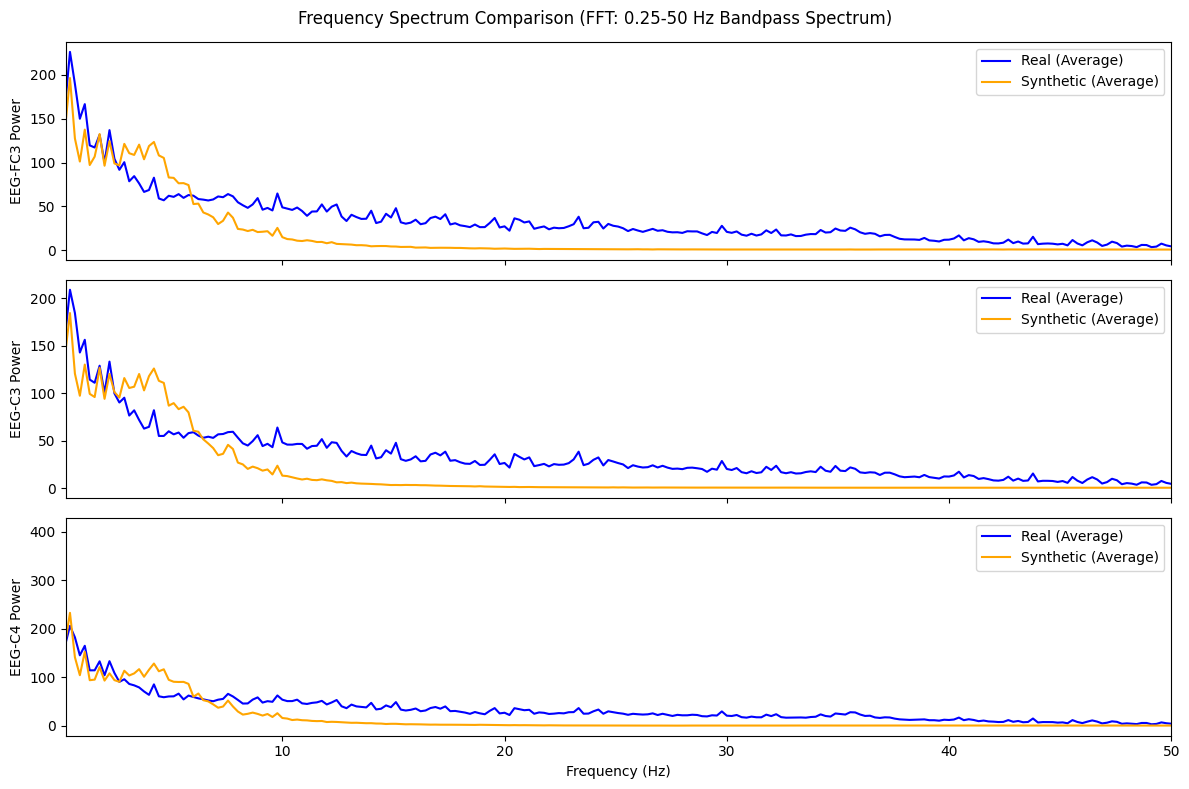

Calculating similarity metrics...
Pearson Correlation per channel (FC3, C3, C4): [np.float64(0.8471), np.float64(0.855), np.float64(0.8595)]
Sliced Wasserstein Distance (SWD): 0.4353


In [5]:
# STEP 1: GENERATE SYNTHETIC DATA FOR SUBJECT 1 DEMO (10 CHANNELS)
print("Training Demo Subject 1 Generator...")
demo_generator = train_wgan_gp_for_subject(X_train_norm_demo, y_train_demo, epochs=100, verbose=True)

noise = np.random.normal(size=(len(y_train_demo), latent_dim)).astype(np.float32)
y_fake = y_train_demo.copy()
synthetic_raw = demo_generator.predict([noise, y_fake[:, np.newaxis]], verbose=0)

# Transpose back to (samples, channels, time) format
X_fake = np.transpose(synthetic_raw, (0, 2, 1))
print("Generated synthetic EEG shape:", X_fake.shape)

# STEP 2: TIME DOMAIN PLOTS (FC3, C3, C4 corresponding to indices 0, 2, 4 in 10 optimal channels)
trial_idx = 0
channels_to_plot = ["EEG-FC3", "EEG-C3", "EEG-C4"]
channel_indices = [0, 2, 4]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for plot_idx, ch_idx in enumerate(channel_indices):
    axes[plot_idx].plot(X_train_norm_demo[trial_idx, ch_idx, :], label="Real", color="blue", alpha=0.7)
    axes[plot_idx].plot(X_fake[trial_idx, ch_idx, :], label="Synthetic", color="orange", alpha=0.7)
    axes[plot_idx].set_ylabel(channels_to_plot[plot_idx])
    axes[plot_idx].legend()

axes[2].set_xlabel("Samples (Time points)")
plt.suptitle(f"Time-Domain Comparison (Trial {trial_idx} | Label {y_train_demo[trial_idx]})")
plt.tight_layout()
plt.show()

# STEP 3: FREQUENCY SPECTRA PLOTS (FFT: 0.25-50 Hz bandpass spectrum)
sfreq = 250
freqs = np.fft.rfftfreq(1125, d=1/sfreq)

real_fft = np.abs(np.fft.rfft(X_train_norm_demo, axis=2))
fake_fft = np.abs(np.fft.rfft(X_fake, axis=2))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for plot_idx, ch_idx in enumerate(channel_indices):
    axes[plot_idx].plot(freqs, real_fft.mean(axis=0)[ch_idx, :], label="Real (Average)", color="blue")
    axes[plot_idx].plot(freqs, fake_fft.mean(axis=0)[ch_idx, :], label="Synthetic (Average)", color="orange")
    axes[plot_idx].set_xlim(0.25, 50) # Focus on filter band range
    axes[plot_idx].set_ylabel(f"{channels_to_plot[plot_idx]} Power")
    axes[plot_idx].legend()

axes[2].set_xlabel("Frequency (Hz)")
plt.suptitle("Frequency Spectrum Comparison (FFT: 0.25-50 Hz Bandpass Spectrum)")
plt.tight_layout()
plt.show()

# STEP 4: QUANTITATIVE METRICS
print("Calculating similarity metrics...")

# Pearson Correlation
pearson_coeffs = []
for ch in channel_indices:
    avg_real = np.mean(X_train_norm_demo[:, ch, :], axis=0)
    avg_fake = np.mean(X_fake[:, ch, :], axis=0)
    r, _ = scipy.stats.pearsonr(avg_real, avg_fake)
    pearson_coeffs.append(r)

print(f"Pearson Correlation per channel (FC3, C3, C4): {[round(x, 4) for x in pearson_coeffs]}")

# Sliced Wasserstein Distance (SWD)
def sliced_wasserstein_distance(X_real_data, X_fake_data, n_projections=50):
    N_real = X_real_data.shape[0]
    N_fake = X_fake_data.shape[0]
    real_flat = X_real_data.reshape(N_real, -1)
    fake_flat = X_fake_data.reshape(N_fake, -1)
    dim = real_flat.shape[1]
    
    swd_sum = 0.0
    for _ in range(n_projections):
        proj = np.random.normal(size=(dim,))
        proj /= np.linalg.norm(proj)
        p_real = np.dot(real_flat, proj)
        p_fake = np.dot(fake_flat, proj)
        swd_sum += scipy.stats.wasserstein_distance(p_real, p_fake)
    return swd_sum / n_projections

swd_score = sliced_wasserstein_distance(X_train_norm_demo, X_fake)
print(f"Sliced Wasserstein Distance (SWD): {swd_score:.4f}")


### PHASE 4: DATA AUGMENTATION & SUBJECT-WISE CLASSIFICATION
Evaluating classification models trained on WGAN-GP augmented datasets vs. real-only datasets, evaluated on clean unseen real trials.


In [ ]:
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]
    
    # Shared MLP layers
    shared_layer_one = tf.keras.layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = tf.keras.layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_three = tf.keras.layers.Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    
    # AvgPool and MaxPool
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)
    
    # Pass through shared MLP
    avg_out = shared_layer_three(shared_layer_two(shared_layer_one(avg_pool)))
    max_out = shared_layer_three(shared_layer_two(shared_layer_one(max_pool)))
    
    # Sum and apply sigmoid
    channel_attention = tf.keras.layers.Add()([avg_out, max_out])
    channel_attention = tf.keras.layers.Activation('sigmoid')(channel_attention)
    
    # Reshape for multiplication
    channel_attention = tf.keras.layers.Reshape((1, 1, channel))(channel_attention)
    
    # Elementwise multiplication
    refined_feature = tf.keras.layers.Multiply()([input_feature, channel_attention])
    
    # Spatial Attention
    avg_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(refined_feature)
    max_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(refined_feature)
    
    # Concatenate along channel dimension
    spatial_concat = tf.keras.layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    
    # Conv2D with kernel 7x7, padding='same', Sigmoid activation
    spatial_attention = tf.keras.layers.Conv2D(filters=1, kernel_size=(7, 7), padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=True)(spatial_concat)
    
    # Elementwise multiplication
    final_feature = tf.keras.layers.Multiply()([refined_feature, spatial_attention])
    
    return final_feature

def make_fcnna(C=10, T=1125):
    inputs = tf.keras.layers.Input(shape=(C, T, 1))
    
    # Branch 1
    # 1. Temporal Conv (C1)
    b1_c1 = tf.keras.layers.Conv2D(96, kernel_size=(1, 60), padding='same')(inputs)
    b1_bn1 = tf.keras.layers.BatchNormalization()(b1_c1)
    # 2. Spatial Depthwise Conv (C2)
    b1_c2 = tf.keras.layers.DepthwiseConv2D(depth_multiplier=2, kernel_size=(C, 1), padding='valid', depthwise_constraint=tf.keras.constraints.MaxNorm(max_value=1.0))(b1_bn1)
    b1_bn2 = tf.keras.layers.BatchNormalization()(b1_c2)
    b1_a1 = tf.keras.layers.Activation('elu')(b1_bn2)
    b1_p1 = tf.keras.layers.AveragePooling2D(pool_size=(1, 4))(b1_a1)
    b1_d1 = tf.keras.layers.Dropout(0.5)(b1_p1)
    
    # 3. Separable Conv (C3)
    b1_c3 = tf.keras.layers.SeparableConv2D(192, kernel_size=(1, 16), padding='same')(b1_d1)
    b1_bn3 = tf.keras.layers.BatchNormalization()(b1_c3)
    b1_a2 = tf.keras.layers.Activation('elu')(b1_bn3)
    b1_p2 = tf.keras.layers.AveragePooling2D(pool_size=(1, 8))(b1_a2)
    b1_d2 = tf.keras.layers.Dropout(0.5)(b1_p2)
    
    # 4. CBAM
    b1_att = cbam_block(b1_d2, ratio=8)
    
    # Branch 2
    # 1. Temporal Conv (C1)
    b2_c1 = tf.keras.layers.Conv2D(16, kernel_size=(1, 64), padding='same')(inputs)
    b2_bn1 = tf.keras.layers.BatchNormalization()(b2_c1)
    # 2. Spatial Depthwise Conv (C2)
    b2_c2 = tf.keras.layers.DepthwiseConv2D(depth_multiplier=1, kernel_size=(C, 1), padding='valid', depthwise_constraint=tf.keras.constraints.MaxNorm(max_value=1.0))(b2_bn1)
    b2_bn2 = tf.keras.layers.BatchNormalization()(b2_c2)
    b2_a1 = tf.keras.layers.Activation('elu')(b2_bn2)
    b2_p1 = tf.keras.layers.AveragePooling2D(pool_size=(1, 4))(b2_a1)
    b2_d1 = tf.keras.layers.Dropout(0.5)(b2_p1)
    
    # 3. Separable Conv (C3)
    b2_c3 = tf.keras.layers.SeparableConv2D(16, kernel_size=(1, 16), padding='same')(b2_d1)
    b2_bn3 = tf.keras.layers.BatchNormalization()(b2_c3)
    b2_a2 = tf.keras.layers.Activation('elu')(b2_bn3)
    b2_p2 = tf.keras.layers.AveragePooling2D(pool_size=(1, 8))(b2_a2)
    b2_d2 = tf.keras.layers.Dropout(0.5)(b2_p2)
    
    # 4. CBAM
    b2_att = cbam_block(b2_d2, ratio=4)
    
    # Classification Head
    # Concatenate along channel dimension (axis=-1)
    concat = tf.keras.layers.Concatenate(axis=-1)([b1_att, b2_att])
    # Flatten
    flat = tf.keras.layers.Flatten()(concat)
    # Dense output with Softmax (N = 2)
    outputs = tf.keras.layers.Dense(2, activation='softmax')(flat)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="FCNNA")
    return model



# STEP 2: DEFINE SUBJECT-WISE PIPELINE LOOP (E-FILES TESTING)
def train_and_evaluate_subject(subject_id, epochs_wgan=100, num_runs=2):
    # 1. Load single-subject training (T) and evaluation (E) datasets
    X_train_split, y_train_split = load_and_preprocess_subject(subject_id)
    X_test_split, y_test_split = load_and_preprocess_subject_evaluation(subject_id)
    
    # 2. Z-score normalize splits individually
    X_train_subj, X_test_subj = z_score_normalize_subject(X_train_split, X_test_split)
    
    # 4. Train Subject-Specific WGAN-GP on the real training split
    print(f"-> Training WGAN-GP on Subject A{subject_id:02d} for {epochs_wgan} epochs...")
    generator_subj = train_wgan_gp_for_subject(X_train_subj, y_train_split, epochs=epochs_wgan, verbose=False)
    
    # 5. Generate synthetic trials for the training split
    noise_train = np.random.normal(size=(len(X_train_subj), latent_dim)).astype(np.float32)
    y_fake_train = y_train_split.copy()
    synthetic_raw_train = generator_subj.predict([noise_train, y_fake_train[:, np.newaxis]], verbose=0)
    X_fake_train = np.transpose(synthetic_raw_train, (0, 2, 1))

    # Augmented training set (Real Train + Synthetic Train)
    X_aug_train = np.concatenate([X_train_subj, X_fake_train], axis=0)
    y_aug_train = np.concatenate([y_train_split, y_fake_train], axis=0)

    # Shuffle the augmented training portion
    shuffle_idx = np.random.permutation(len(X_aug_train))
    X_aug_train = X_aug_train[shuffle_idx]
    y_aug_train = y_aug_train[shuffle_idx]
    
    # Reshape for FCNNA input format (trials, channels, time, 1)
    X_aug_train_fcnna = np.expand_dims(X_aug_train, axis=-1)
    X_test_subj_fcnna = np.expand_dims(X_test_subj, axis=-1)
    
    # One-hot encode the target labels
    y_aug_train_onehot = tf.keras.utils.to_categorical(y_aug_train, num_classes=2)
    y_test_split_onehot = tf.keras.utils.to_categorical(y_test_split, num_classes=2)
    
    best_acc = 0.0
    best_metrics = (0.0, 0.0, 0.0, 0.0)
    
    # 6. Train FCNNA Classifier on the augmented training split (multiple runs for robustness)
    for run in range(num_runs):
        print(f"  -> Run {run+1}/{num_runs} FCNNA Training...")
        model = make_fcnna(C=10, T=1125)
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0009)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        
        # Callbacks
        checkpoint_filepath = f"best_model_subj_{subject_id}_run_{run}.weights.h5"
        checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_filepath,
            save_best_only=True,
            save_weights_only=True,
            monitor="val_accuracy",
            mode="max",
            verbose=0
        )
        early_stopping_cb = tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=0
        )
        
        # Train the model
        model.fit(
            X_aug_train_fcnna,
            y_aug_train_onehot,
            epochs=300,
            batch_size=64,
            validation_data=(X_test_subj_fcnna, y_test_split_onehot),
            callbacks=[checkpoint_cb, early_stopping_cb],
            verbose=0
        )
        
        # Ensure best weights are loaded
        try:
            model.load_weights(checkpoint_filepath)
        except Exception as e:
            pass
        
        # 7. Evaluate on the real test split
        preds_prob = model.predict(X_test_subj_fcnna, verbose=0)
        preds_aug = np.argmax(preds_prob, axis=1)
        
        acc = accuracy_score(y_test_split, preds_aug)
        prec = precision_score(y_test_split, preds_aug, average="macro", zero_division=0)
        rec = recall_score(y_test_split, preds_aug, average="macro", zero_division=0)
        f1 = f1_score(y_test_split, preds_aug, average="macro", zero_division=0)
        
        if acc > best_acc:
            best_acc = acc
            best_metrics = (acc, prec, rec, f1)
            
    return best_metrics


In [15]:
# STEP 3: RUN PIPELINE WITH WGAN-GP DATA AUGMENTATION
print("\n" + "="*79)
print("STARTING INDIVIDUAL SUBJECT FCNNA EVALUATION (WGAN-GP AUGMENTED | 10 CHANNELS)")
print("="*79)

subject_results_augmented = {}

for subject in range(1, 10):
    print(f"\n[SUBJECT A{subject:02d}]")
    acc, prec, rec, f1 = train_and_evaluate_subject(subject, epochs_wgan=100, num_runs=2)
    subject_results_augmented[subject] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    print(f"Subject A{subject:02d} Augmented Results - Best Accuracy: {acc:.4f}, F1: {f1:.4f}")

# Print Summary
print("\n" + "="*79)
print("INDIVIDUAL SUBJECT-WISE EVALUATION SUMMARY (WGAN-GP AUGMENTED | 10 CHANNELS)")
print("="*79)

accs_aug = [res["accuracy"] for res in subject_results_augmented.values()]
precs_aug = [res["precision"] for res in subject_results_augmented.values()]
recs_aug = [res["recall"] for res in subject_results_augmented.values()]
f1s_aug = [res["f1"] for res in subject_results_augmented.values()]

for subject, res in subject_results_augmented.items():
    print(f"Subject A{subject:02d} | Accuracy: {res['accuracy']:.4f} | F1 Score: {res['f1']:.4f}")
    
print("-" * 50)
print(f"Average Accuracy : {np.mean(accs_aug):.4f} +/- {np.std(accs_aug):.4f}")
print(f"Average Precision: {np.mean(precs_aug):.4f} +/- {np.std(precs_aug):.4f}")
print(f"Average Recall   : {np.mean(recs_aug):.4f} +/- {np.std(recs_aug):.4f}")
print(f"Average F1 Score : {np.mean(f1s_aug):.4f} +/- {np.std(f1s_aug):.4f}")
print("="*79 + "\n")



STARTING INDIVIDUAL SUBJECT FCNNA EVALUATION (WGAN-GP AUGMENTED | 10 CHANNELS)

[SUBJECT A01]
-> Training WGAN-GP on Subject A01 for 100 epochs...
  -> Run 1/2 FCNNA Training...
  -> Run 2/2 FCNNA Training...
Subject A01 Augmented Results - Best Accuracy: 0.5347, F1: 0.5336

[SUBJECT A02]
-> Training WGAN-GP on Subject A02 for 100 epochs...
  -> Run 1/2 FCNNA Training...
  -> Run 2/2 FCNNA Training...
Subject A02 Augmented Results - Best Accuracy: 0.5417, F1: 0.5416

[SUBJECT A03]
-> Training WGAN-GP on Subject A03 for 100 epochs...
  -> Run 1/2 FCNNA Training...
  -> Run 2/2 FCNNA Training...
Subject A03 Augmented Results - Best Accuracy: 0.5556, F1: 0.5500

[SUBJECT A04]
-> Training WGAN-GP on Subject A04 for 100 epochs...
  -> Run 1/2 FCNNA Training...


KeyboardInterrupt: 

#### Training / Testing FCNNA on Real only data

In [22]:
# STEP 5: SUBJECT-WISE PIPELINE FOR REAL DATA ONLY (NO WGAN-GP AUGMENTATION)
def train_and_evaluate_subject_real_only(subject_id, num_runs=2):          # train 3 times for each subject and give best acc for that subject
    # 1. Load single-subject training (T) and evaluation (E) datasets
    X_train_split, y_train_split = load_and_preprocess_subject(subject_id)
    X_test_split, y_test_split = load_and_preprocess_subject_evaluation(subject_id)
    
    # 2. Z-score normalize splits individually
    X_train_subj, X_test_subj = z_score_normalize_subject(X_train_split, X_test_split)
    
    # Reshape for FCNNA input format
    X_train_fcnna = np.expand_dims(X_train_subj, axis=-1)
    X_test_fcnna = np.expand_dims(X_test_subj, axis=-1)
    
    y_train_onehot = tf.keras.utils.to_categorical(y_train_split, num_classes=2)
    y_test_onehot = tf.keras.utils.to_categorical(y_test_split, num_classes=2)
    
    best_acc = 0.0
    best_metrics = (0.0, 0.0, 0.0, 0.0)
    
    for run in range(num_runs):
        print(f"  -> Run {run+1}/{num_runs} FCNNA Training (Real Data Only)...")
        model = make_fcnna(C=10, T=1125)
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0009)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        
        checkpoint_filepath = f"best_model_subj_{subject_id}_real_run_{run}.weights.h5"
        checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_filepath,
            save_best_only=True,
            save_weights_only=True,
            monitor="val_accuracy",
            mode="max",
            verbose=0
        )
        early_stopping_cb = tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=0
        )
        
        model.fit(
            X_train_fcnna,
            y_train_onehot,
            epochs=200,
            batch_size=64,
            validation_data=(X_test_fcnna, y_test_onehot),
            callbacks=[checkpoint_cb, early_stopping_cb],
            verbose=0
        )
        
        try:
            model.load_weights(checkpoint_filepath)
        except Exception as e:
            pass
            
        preds_prob = model.predict(X_test_fcnna, verbose=0)
        preds_aug = np.argmax(preds_prob, axis=1)
        
        acc = accuracy_score(y_test_split, preds_aug)
        prec = precision_score(y_test_split, preds_aug, average="macro", zero_division=0)
        rec = recall_score(y_test_split, preds_aug, average="macro", zero_division=0)
        f1 = f1_score(y_test_split, preds_aug, average="macro", zero_division=0)
        
        if acc > best_acc:
            best_acc = acc
            best_metrics = (acc, prec, rec, f1)
            
    return best_metrics


In [23]:
# STEP 6: RUN PIPELINE FOR REAL DATA ONLY (BASELINE)
print("\n" + "="*79)
print("STARTING INDIVIDUAL SUBJECT FCNNA EVALUATION (REAL DATA ONLY | 10 CHANNELS)")
print("="*79)

subject_results_real = {}

for subject in range(1, 10):
    print(f"\n[SUBJECT A{subject:02d}]")
    acc, prec, rec, f1 = train_and_evaluate_subject_real_only(subject, num_runs=2)
    subject_results_real[subject] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    print(f"Subject A{subject:02d} Real-Only Results - Best Accuracy: {acc:.4f}, F1: {f1:.4f}")

# Print Summary
print("\n" + "="*79)
print("INDIVIDUAL SUBJECT-WISE EVALUATION SUMMARY (REAL DATA ONLY | 10 CHANNELS)")
print("="*79)

accs_real = [res["accuracy"] for res in subject_results_real.values()]
precs_real = [res["precision"] for res in subject_results_real.values()]
recs_real = [res["recall"] for res in subject_results_real.values()]
f1s_real = [res["f1"] for res in subject_results_real.values()]

for subject, res in subject_results_real.items():
    print(f"Subject A{subject:02d} | Accuracy: {res['accuracy']:.4f} | F1 Score: {res['f1']:.4f}")
    
print("-" * 50)
print(f"Average Accuracy : {np.mean(accs_real):.4f} +/- {np.std(accs_real):.4f}")
print(f"Average Precision: {np.mean(precs_real):.4f} +/- {np.std(precs_real):.4f}")
print(f"Average Recall   : {np.mean(recs_real):.4f} +/- {np.std(recs_real):.4f}")
print(f"Average F1 Score : {np.mean(f1s_real):.4f} +/- {np.std(f1s_real):.4f}")
print("="*79 + "\n")



STARTING INDIVIDUAL SUBJECT FCNNA EVALUATION (REAL DATA ONLY | 10 CHANNELS)

[SUBJECT A01]
  -> Run 1/2 FCNNA Training (Real Data Only)...
  -> Run 2/2 FCNNA Training (Real Data Only)...
Subject A01 Real-Only Results - Best Accuracy: 0.5903, F1: 0.5845

[SUBJECT A02]
  -> Run 1/2 FCNNA Training (Real Data Only)...
  -> Run 2/2 FCNNA Training (Real Data Only)...
Subject A02 Real-Only Results - Best Accuracy: 0.6389, F1: 0.6378

[SUBJECT A03]
  -> Run 1/2 FCNNA Training (Real Data Only)...
  -> Run 2/2 FCNNA Training (Real Data Only)...
Subject A03 Real-Only Results - Best Accuracy: 0.5208, F1: 0.4975

[SUBJECT A04]
  -> Run 1/2 FCNNA Training (Real Data Only)...
  -> Run 2/2 FCNNA Training (Real Data Only)...
Subject A04 Real-Only Results - Best Accuracy: 0.5069, F1: 0.3991

[SUBJECT A05]
  -> Run 1/2 FCNNA Training (Real Data Only)...
  -> Run 2/2 FCNNA Training (Real Data Only)...
Subject A05 Real-Only Results - Best Accuracy: 0.5625, F1: 0.5152

[SUBJECT A06]
  -> Run 1/2 FCNNA Trai

KeyboardInterrupt: 